# 01 — EDA

Distribution exploration: class breakdowns, missing data, score outliers.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../scores.db')
df = pd.read_sql('SELECT * FROM performances', conn)
scores_df = pd.read_sql('SELECT * FROM scores', conn)

print(df.shape, scores_df.shape)

(4441, 19) (56910, 9)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4441 entries, 0 to 4440
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   performance_key       4441 non-null   str    
 1   content_hash          4441 non-null   str    
 2   ensemble_name         4441 non-null   str    
 3   ensemble_slug         4441 non-null   str    
 4   ensemble_location     2219 non-null   str    
 5   class_code            4441 non-null   str    
 6   class_name_raw        4441 non-null   str    
 7   performance_date      4441 non-null   str    
 8   round                 898 non-null    float64
 9   competition_name      4441 non-null   str    
 10  competition_slug      4441 non-null   str    
 11  competition_location  4441 non-null   str    
 12  subtotal_score        4441 non-null   float64
 13  subtotal_rank         4441 non-null   int64  
 14  penalty_score         4441 non-null   float64
 15  total_score           4441 non-n

In [3]:
# Missing values
df.isnull().sum().sort_values(ascending=False)

round                   3543
ensemble_location       2222
performance_key            0
competition_location       0
placement                  0
total_rank                 0
total_score                0
penalty_score              0
subtotal_rank              0
subtotal_score             0
competition_name           0
competition_slug           0
content_hash               0
performance_date           0
class_name_raw             0
class_code                 0
ensemble_slug              0
ensemble_name              0
ingested_at                0
dtype: int64

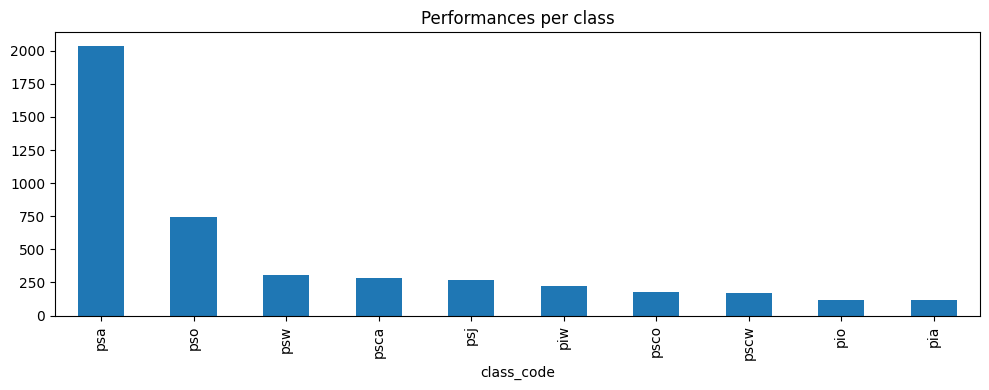

In [4]:
# Performance counts by class
df['class_code'].value_counts().plot(kind='bar', figsize=(10, 4), title='Performances per class')
plt.tight_layout()

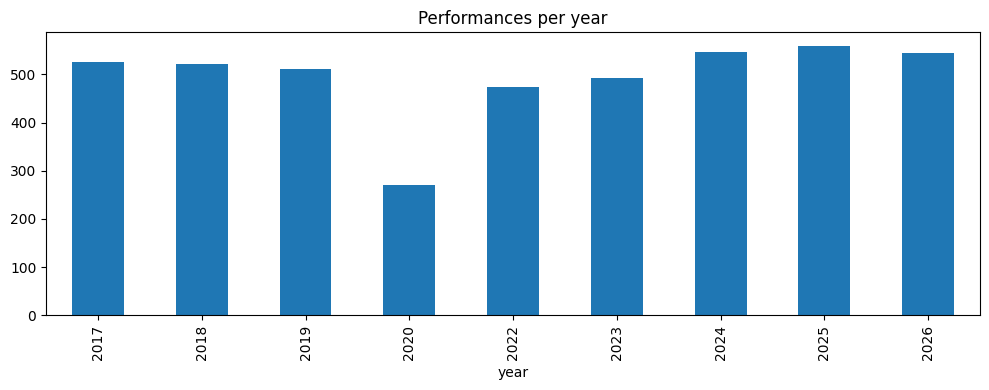

In [5]:
# Performance counts by year
df['year'] = df['performance_date'].str[:4]
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(10, 4), title='Performances per year')
plt.tight_layout()

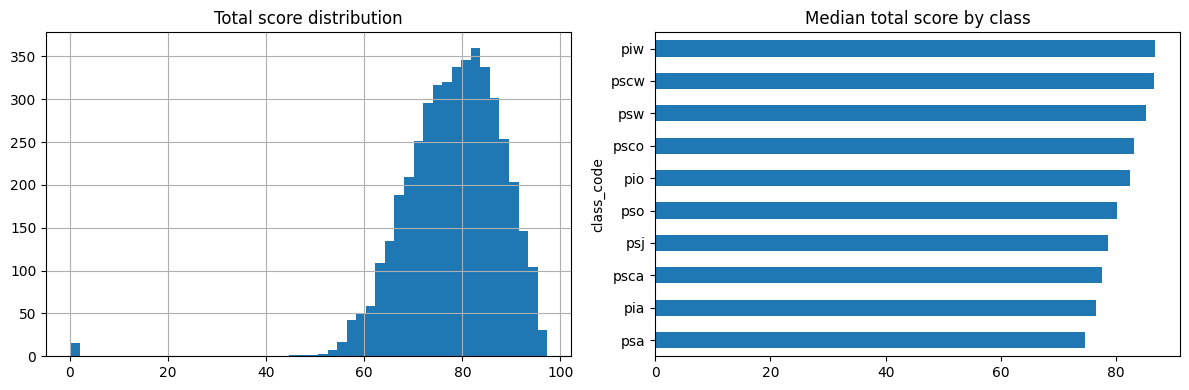

In [6]:
# Total score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['total_score'].hist(bins=50, ax=axes[0])
axes[0].set_title('Total score distribution')

df.groupby('class_code')['total_score'].median().sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Median total score by class')
plt.tight_layout()